In [1]:
import pandas as pd
from fontTools.misc.arrayTools import offsetRect

df = pd.read_csv('brasileirao_2026.csv')

print(f"Jogos carregados: {len(df)}")
print(f"Rodadas: {df['rodada'].min()} a {df['rodada'].max()}")
df.head()

Jogos carregados: 63
Rodadas: 1 a 7


,data,rodada,status,time_casa,time_fora,gols_casa,gols_fora
0,2026-01-28,1,FINISHED,CA Mineiro,SE Palmeiras,2.0,2.0
1,2026-01-28,1,FINISHED,Coritiba FBC,RB Bragantino,0.0,1.0
2,2026-01-28,1,FINISHED,SC Internacional,CA Paranaense,0.0,1.0
3,2026-01-28,1,FINISHED,EC Vitória,Clube do Remo,2.0,0.0
4,2026-01-28,1,FINISHED,Fluminense FC,Grêmio FBPA,2.0,1.0


In [4]:
 #Primeiro bloco: Tabela de Desempenho Geral

#Métricas para jogos em casa:
casa = df.groupby('time_casa').agg(
    jogos_casa=('time_casa', 'count'),
    vitorias_casa=('gols_casa', lambda x: ((x > df.loc[x.index, 'gols_fora'])).sum()),
    empates_casa=('gols_casa', lambda x: ((x == df.loc[x.index, 'gols_fora'])).sum()),
    derrotas_casa=('gols_casa', lambda x: ((x < df.loc[x.index, 'gols_fora'])).sum()),
    gols_marcados_casa=('gols_casa', 'sum'),
    gols_sofridos_casa=('gols_fora', 'sum'),
).reset_index().rename(columns={'time_casa': 'time'})

#Métricas para jogos fora:
fora = df.groupby('time_fora').agg(
    jogos_fora=('time_fora', 'count'),
    vitorias_fora=('gols_fora', lambda x: ((x > df.loc[x.index, 'gols_casa'])).sum()),
    empates_fora=('gols_fora', lambda x: ((x == df.loc[x.index, 'gols_casa'])).sum()),
    derrotas_fora=('gols_fora', lambda x: ((x < df.loc[x.index, 'gols_casa'])).sum()),
    gols_marcados_fora=('gols_fora', 'sum'),
    gols_sofridos_fora=('gols_casa', 'sum'),
).reset_index().rename(columns={'time_fora': 'time'})

tabela = pd.merge(casa, fora, on='time')

#Calculando totais:
tabela['jogos']           = tabela['jogos_casa'] + tabela ['jogos_fora']
tabela['vitorias']        = tabela['vitorias_casa'] + tabela['vitorias_fora']
tabela['empates']         = tabela['empates_casa'] + tabela['empates_fora']
tabela['derrotas']        = tabela['derrotas_casa'] + tabela['derrotas_fora']
tabela['pontos']          = tabela['vitorias'] * 3 + tabela['empates']
tabela['gols_marcados']   = tabela['gols_marcados_casa'] + tabela['gols_marcados_fora']
tabela['gols_sofridos']   = tabela['gols_sofridos_casa'] + tabela['gols_sofridos_fora']
tabela['saldo_gols']      = tabela['gols_marcados'] - tabela['gols_sofridos']
tabela['aproveitamento']  = (tabela['pontos'] / (tabela['jogos'] * 3) * 100).round(1)

tabela_final = tabela[[
    'time', 'jogos', 'pontos', 'vitorias', 'empates', 'derrotas',
    'gols_marcados', 'gols_sofridos', 'saldo_gols', 'aproveitamento'
]].sort_values('pontos', ascending=False).reset_index(drop=True)

tabela_final.index += 1

print("\nTabela de Desempenho Geral\n")
tabela_final


Tabela de Desempenho Geral



,time,jogos,pontos,vitorias,empates,derrotas,gols_marcados,gols_sofridos,saldo_gols,aproveitamento
1,São Paulo FC,7,16,5,1,1,10.0,4.0,6.0,76.2
2,SE Palmeiras,7,16,5,1,1,16.0,8.0,8.0,76.2
3,EC Bahia,6,14,4,2,0,8.0,3.0,5.0,77.8
4,Coritiba FBC,7,13,4,1,2,9.0,6.0,3.0,61.9
5,Fluminense FC,7,13,4,1,2,12.0,9.0,3.0,61.9
6,CR Flamengo,5,10,3,1,1,9.0,4.0,5.0,66.7
7,CA Paranaense,6,10,3,1,2,8.0,7.0,1.0,55.6
8,CA Mineiro,7,8,2,2,3,8.0,10.0,-2.0,38.1
9,SC Corinthians Paulista,6,8,2,2,2,6.0,6.0,0.0,44.4
10,Grêmio FBPA,6,8,2,2,2,10.0,10.0,0.0,44.4


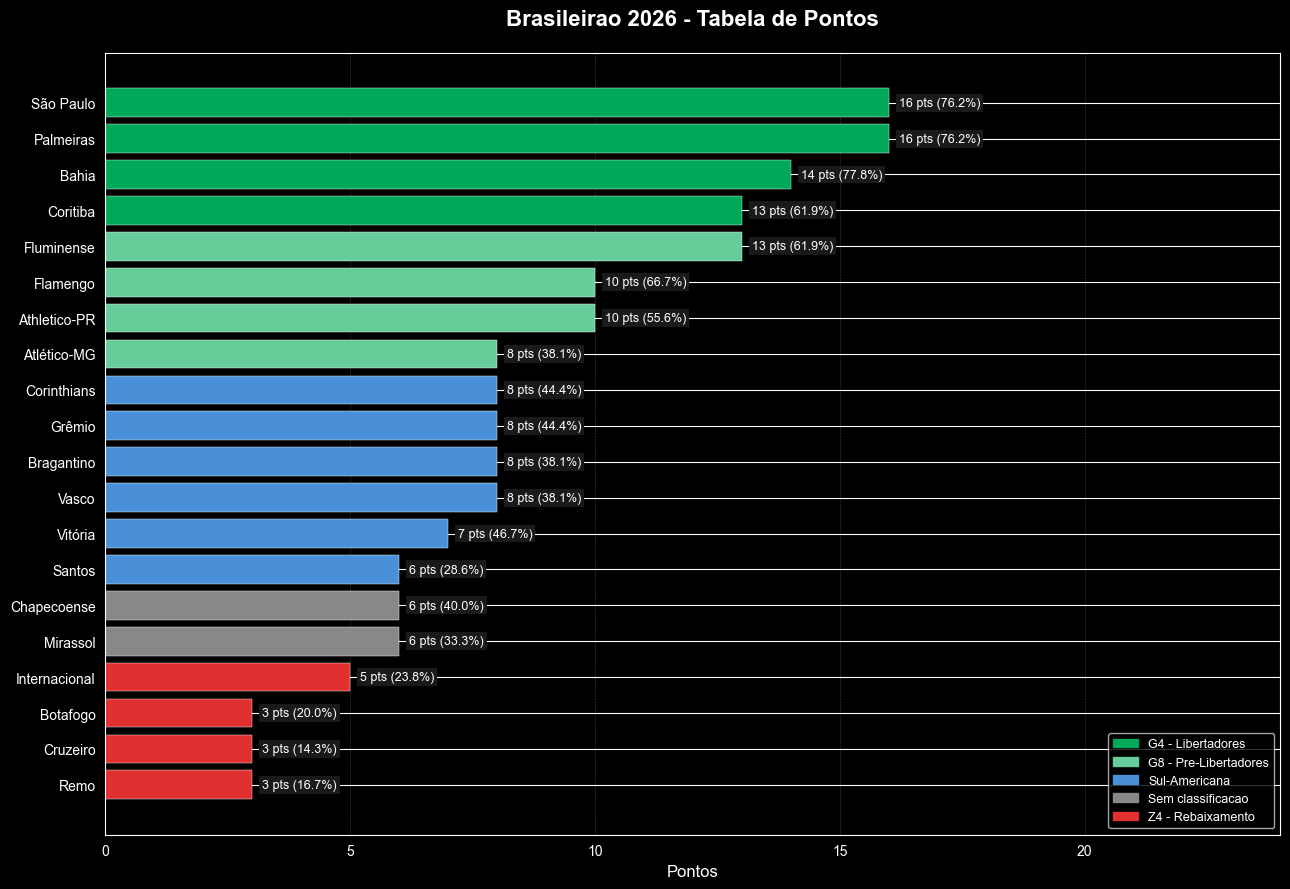

Grafico salvo!


In [16]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

#Mapeamento de nomes populares
nomes_populares = {
    'São Paulo FC': 'São Paulo',
    'SE Palmeiras': 'Palmeiras',
    'EC Bahia': 'Bahia',
    'Coritiba FBC': 'Coritiba',
    'Fluminense FC': 'Fluminense',
    'CR Flamengo': 'Flamengo',
    'CA Paranaense': 'Athletico-PR',
    'CA Mineiro': 'Atlético-MG',
    'SC Corinthians Paulista': 'Corinthians',
    'Grêmio FBPA': 'Grêmio',
    'RB Bragantino': 'Bragantino',
    'CR Vasco da Gama': 'Vasco',
    'EC Vitória': 'Vitória',
    'Santos FC': 'Santos',
    'Chapecoense AF': 'Chapecoense',
    'Mirassol FC': 'Mirassol',
    'SC Internacional': 'Internacional',
    'Botafogo FR': 'Botafogo',
    'Cruzeiro EC': 'Cruzeiro',
    'Clube do Remo': 'Remo',
}

#Aplicando nomes populares
tabela_final['time_popular'] = tabela_final['time'].map(nomes_populares).fillna(tabela_final['time'])

#Configuração do gráfico:
def cor_por_posicao(pos):
    if pos <= 4:
        return '#00A859'    #Verde — Libertadores
    elif pos <= 8:
        return '#66CC99'    #Verde claro — Pré-Libertadores
    elif pos <= 14:
        return '#4A90D9'    #Azul neutro — Sul-Americana
    elif pos <= 16:
        return '#888888'    #Cinza — Sem classificação
    else:
        return '#E03030'    #Vermelho — Rebaixamento

cores = [cor_por_posicao(i+1) for i in range(len(tabela_final))]

#Configuração de plot:
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(14, 9))

bars = ax.barh(
    tabela_final['time_popular'][::-1],
    tabela_final['pontos'][::-1],
    color=cores[::-1],
    edgecolor='white',
    linewidth=0.3
)

#Rótulos de barras:
for bar, pontos, aprov in zip(bars, tabela_final['pontos'][::-1], tabela_final['aproveitamento'][::-1]):
    ax.text(
        bar.get_width() + 0.2,
        bar.get_y() + bar.get_height() / 2,
        f'{pontos} pts ({aprov}%)',
        va='center', ha='left', fontsize=9, color='white',
        bbox=dict(facecolor='#1a1a1a', edgecolor='none', pad=2)  # fundo escuro no texto
    )

ax.xaxis.grid(True, color='gray', linestyle='--', linewidth=0.4, alpha=0.5)
ax.set_axisbelow(True)

#Legendas:
patches = [
    mpatches.Patch(color='#00A859', label='G4 - Libertadores'),
    mpatches.Patch(color='#66CC99', label='G8 - Pre-Libertadores'),
    mpatches.Patch(color='#4A90D9', label='Sul-Americana'),
    mpatches.Patch(color='#888888', label='Sem classificacao'),
    mpatches.Patch(color='#E03030', label='Z4 - Rebaixamento'),
]
ax.legend(handles=patches, loc='lower right', fontsize=9)

# Título e label
ax.set_title('Brasileirao 2026 - Tabela de Pontos', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Pontos', fontsize=12)
ax.set_xlim(0, tabela_final['pontos'].max() + 8)

plt.tight_layout()
plt.subplots_adjust(left=0.15)
plt.savefig('tabela_brasileirao_2026.png', dpi=150, bbox_inches='tight')
plt.show()

print("Grafico salvo!")

In [17]:
#Salvando a tabela final com nomes populares
tabela_final.to_csv('tabela_desempenho_2026.csv', index=False)
print("Salvo")

Salvo


In [4]:
#Segundo bloco: Poder Ofensivo

#Medidas ofensivas
ofensivo = tabela_final[['time_popular', 'jogos', 'gols_marcados']].copy()
ofensivo['media_gols'] = (ofensivo['gols_marcados'] / ofensivo['jogos']).round(2)
ofensivo = ofensivo.sort_values('gols_marcados', ascending=False).reset_index(drop=True)
ofensivo.index += 1

print("BRASILEIRAO 2026 — Ranking Ofensivo")
print(ofensivo.to_string())

BRASILEIRAO 2026 — Ranking Ofensivo
     time_popular  jogos  gols_marcados  media_gols
1       Palmeiras      7           16.0        2.29
2      Fluminense      7           12.0        1.71
3           Vasco      7           11.0        1.57
4       São Paulo      7           10.0        1.43
5          Grêmio      6           10.0        1.67
6          Santos      7           10.0        1.43
7     Chapecoense      5            9.0        1.80
8        Coritiba      7            9.0        1.29
9        Flamengo      5            9.0        1.80
10          Bahia      6            8.0        1.33
11    Atlético-MG      7            8.0        1.14
12   Athletico-PR      6            8.0        1.33
13       Cruzeiro      7            8.0        1.14
14       Botafogo      5            8.0        1.60
15       Mirassol      6            8.0        1.33
16        Vitória      5            7.0        1.40
17           Remo      6            6.0        1.00
18    Corinthians      6    

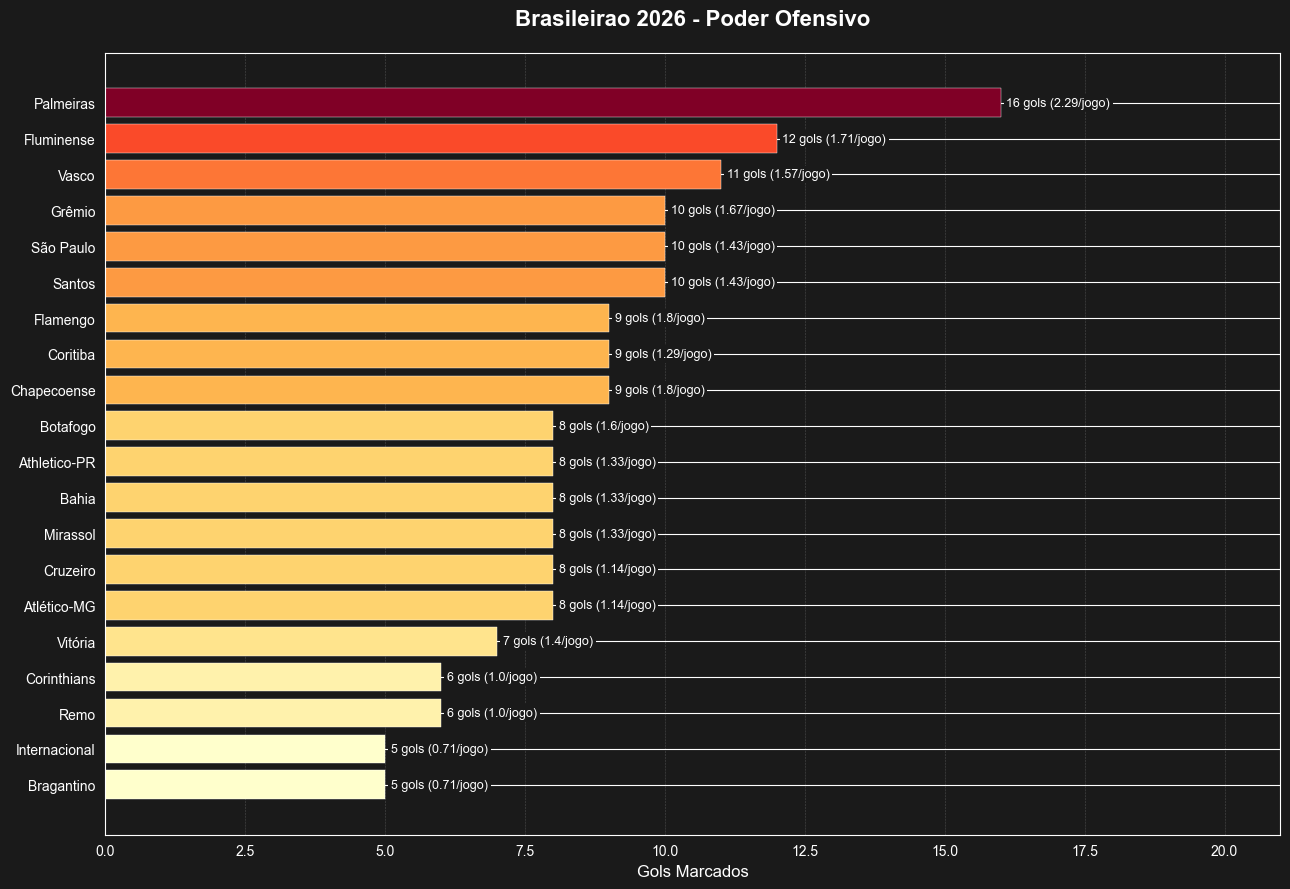

Grafico salvo


In [5]:
#Gráfico segundo bloco: Poder Ofensivo

fig, ax = plt.subplots(figsize=(14, 9))
plt.style.use('dark_background')
fig.patch.set_facecolor('#1a1a1a')
ax.set_facecolor('#1a1a1a')

plot_data = ofensivo.sort_values('gols_marcados', ascending=True)

#Cor gradiente por gols - quanto mais gols, mais forte
import matplotlib.cm as cm
import numpy as np

norm = plt.Normalize(plot_data['gols_marcados'].min(), plot_data['gols_marcados'].max())
cores = cm.YlOrRd(norm(plot_data['gols_marcados'].values))

bars = ax.barh(
    plot_data['time_popular'],
    plot_data['gols_marcados'],
    color=cores,
    edgecolor='white',
    linewidth=0.3
)

#Rótulo de dados:
for bar, gols, media in zip(bars, plot_data['gols_marcados'], plot_data['media_gols']):
    ax.text(
        bar.get_width() + 0.1,
        bar.get_y() + bar.get_height() / 2,
        f'{int(gols)} gols ({media}/jogo)',
        va='center', ha='left', fontsize=9, color='white',
        bbox=dict(facecolor='#1a1a1a', edgecolor='none', pad=2)
    )

#Grade:
ax.xaxis.grid(True, color='gray', linestyle='--', linewidth=0.4, alpha=0.5)
ax.set_axisbelow(True)

#Títulos:
ax.set_title('Brasileirao 2026 - Poder Ofensivo', fontsize=16, fontweight='bold', pad=20, color='white')
ax.set_xlabel('Gols Marcados', fontsize=12, color='white')
ax.tick_params(colors='white')
ax.set_xlim(0, plot_data['gols_marcados'].max() + 5)

plt.tight_layout()
plt.subplots_adjust(left=0.15)
plt.savefig('poder_ofensivo_2026.png', dpi=150, bbox_inches='tight')
plt.show()

print("Grafico salvo")

In [6]:
ofensivo.to_csv('poder_ofensivo_2026.csv', index=False)
print("Salvo!")

Salvo!


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

df = pd.read_csv('brasileirao_2026.csv')
tabela_final = pd.read_csv('tabela_desempenho_2026.csv')

print("Dados carregados!")
print(f"Times: {len(tabela_final)}")

Dados carregados!
Times: 20


In [4]:
#Terceiro bloco: Solidez Defensiva

defensivo = tabela_final[['time_popular', 'jogos', 'gols_sofridos']].copy()
defensivo['media_sofridos'] = (defensivo['gols_sofridos'] / defensivo['jogos']).round(2)
defensivo = defensivo.sort_values('gols_sofridos', ascending=True).reset_index(drop=True)
defensivo.index += 1

print("BRASILEIRAO 2026 — Ranking Defensivo")
print(defensivo.to_string())

BRASILEIRAO 2026 — Ranking Defensivo
     time_popular  jogos  gols_sofridos  media_sofridos
1           Bahia      6            3.0            0.50
2       São Paulo      7            4.0            0.57
3        Flamengo      5            4.0            0.80
4        Coritiba      7            6.0            0.86
5     Corinthians      6            6.0            1.00
6    Athletico-PR      6            7.0            1.17
7      Bragantino      7            8.0            1.14
8       Palmeiras      7            8.0            1.14
9         Vitória      5            8.0            1.60
10     Fluminense      7            9.0            1.29
11       Mirassol      6            9.0            1.50
12    Chapecoense      5            9.0            1.80
13  Internacional      7            9.0            1.29
14    Atlético-MG      7           10.0            1.43
15         Grêmio      6           10.0            1.67
16       Botafogo      5           11.0            2.20
17         

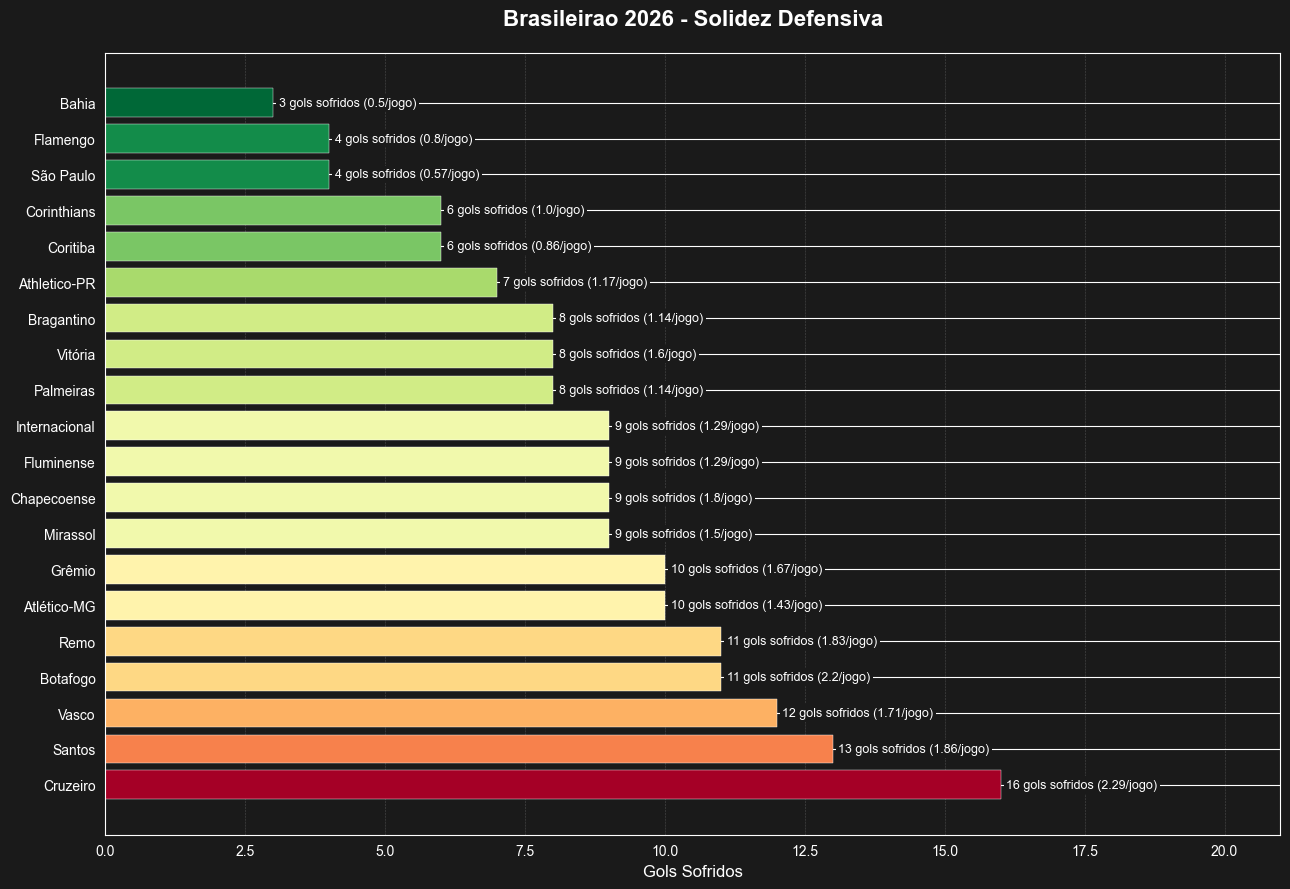

Grafico salvo


In [5]:
# Gráfico Terceiro Bloco: Solidez Defensiva
fig, ax = plt.subplots(figsize=(14, 9))
plt.style.use('dark_background')
fig.patch.set_facecolor('#1a1a1a')
ax.set_facecolor('#1a1a1a')

# Ordenando — menos gols sofridos no topo
plot_data = defensivo.sort_values('gols_sofridos', ascending=False)

# Gradiente — menos gols sofridos = mais verde
norm = plt.Normalize(plot_data['gols_sofridos'].min(), plot_data['gols_sofridos'].max())
cores = cm.RdYlGn_r(norm(plot_data['gols_sofridos'].values))

bars = ax.barh(
    plot_data['time_popular'],
    plot_data['gols_sofridos'],
    color=cores,
    edgecolor='white',
    linewidth=0.3
)

# Rótulo de Dados
for bar, gols, media in zip(bars, plot_data['gols_sofridos'], plot_data['media_sofridos']):
    ax.text(
        bar.get_width() + 0.1,
        bar.get_y() + bar.get_height() / 2,
        f'{int(gols)} gols sofridos ({media}/jogo)',
        va='center', ha='left', fontsize=9, color='white',
        bbox=dict(facecolor='#1a1a1a', edgecolor='none', pad=2)
    )

# Grade
ax.xaxis.grid(True, color='gray', linestyle='--', linewidth=0.4, alpha=0.5)
ax.set_axisbelow(True)

# Títulos
ax.set_title('Brasileirao 2026 - Solidez Defensiva', fontsize=16, fontweight='bold', pad=20, color='white')
ax.set_xlabel('Gols Sofridos', fontsize=12, color='white')
ax.tick_params(colors='white')
ax.set_xlim(0, plot_data['gols_sofridos'].max() + 5)

plt.tight_layout()
plt.subplots_adjust(left=0.15)
plt.savefig('solidez_defensiva_2026.png', dpi=150, bbox_inches='tight')
plt.show()

print("Grafico salvo")

In [6]:
defensivo.to_csv('solidez_defensiva_2026.csv', index=False)
print("Salvo")

Salvo


In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as cm
import numpy as np

#Carregando os dados
df = pd.read_csv('brasileirao_2026.csv')
tabela_final = pd.read_csv('tabela_desempenho_2026.csv')

print("Dados carregados")

Dados carregados


In [14]:
#Quarto bloco: Saldo de Gols

#Criando o dataframe
saldo = tabela_final[['time_popular', 'gols_marcados', 'gols_sofridos']].copy()

saldo['saldo_gols'] = saldo['gols_marcados'] - saldo['gols_sofridos']

saldo = saldo.sort_values('saldo_gols', ascending=False).reset_index(drop=True)
saldo.index += 1

print("Brasileirao 2026 - Saldo de Gols")
print('_' * 40)
print(saldo.to_string())

Brasileirao 2026 - Saldo de Gols
________________________________________
     time_popular  gols_marcados  gols_sofridos  saldo_gols
1       Palmeiras           16.0            8.0         8.0
2       São Paulo           10.0            4.0         6.0
3           Bahia            8.0            3.0         5.0
4        Flamengo            9.0            4.0         5.0
5        Coritiba            9.0            6.0         3.0
6      Fluminense           12.0            9.0         3.0
7    Athletico-PR            8.0            7.0         1.0
8     Corinthians            6.0            6.0         0.0
9          Grêmio           10.0           10.0         0.0
10    Chapecoense            9.0            9.0         0.0
11        Vitória            7.0            8.0        -1.0
12          Vasco           11.0           12.0        -1.0
13       Mirassol            8.0            9.0        -1.0
14    Atlético-MG            8.0           10.0        -2.0
15     Bragantino         

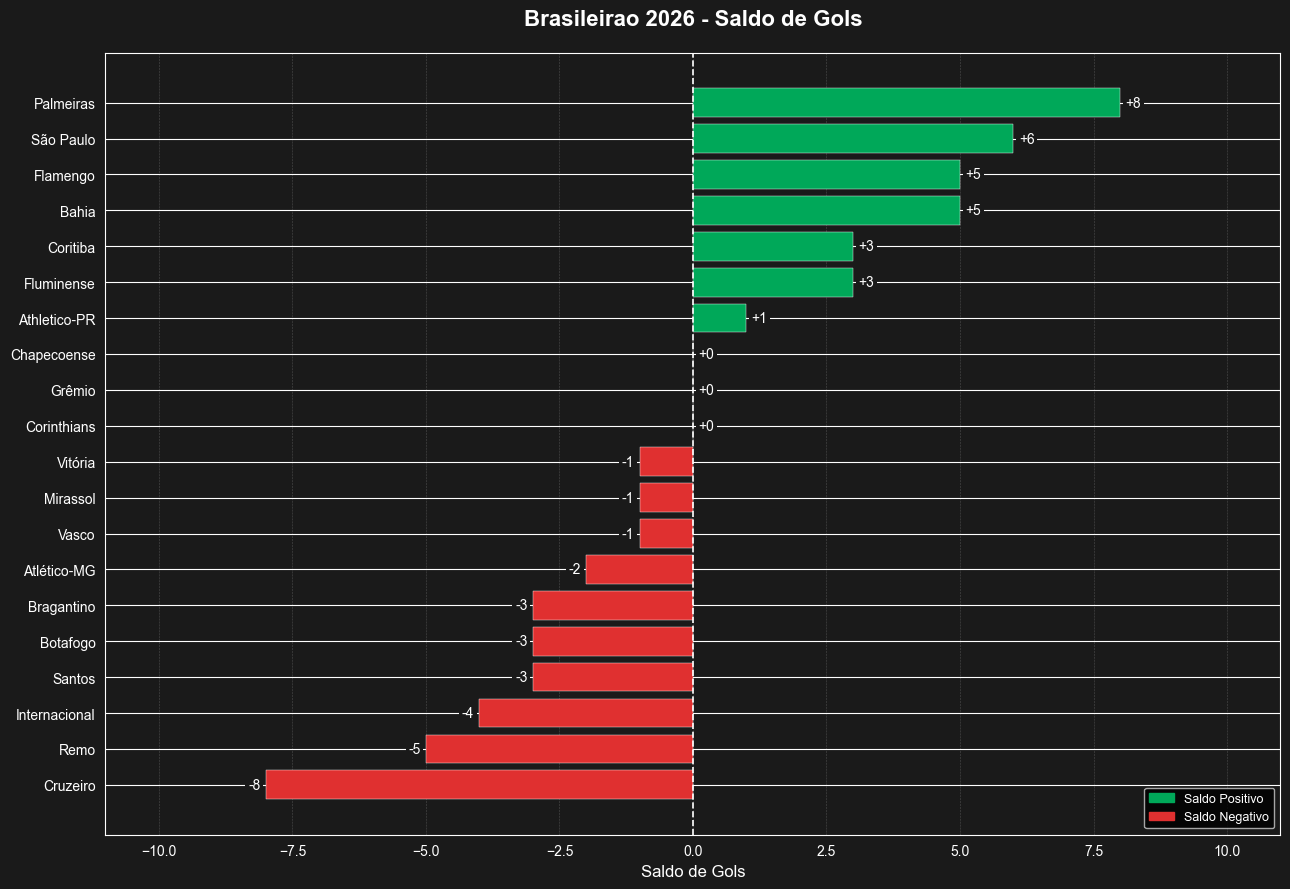

Grafico salvo


In [15]:
#Criação do Gráfio de Saldo de Gols:

plot_data = saldo.sort_values('saldo_gols', ascending=True)

cores = ['#00A859' if s >= 0 else '#E03030' for s in plot_data['saldo_gols']]

#Criação da figura:
fig, ax = plt.subplots(figsize=(14, 9))
plt.style.use('dark_background')
fig.patch.set_facecolor('#1a1a1a')
ax.set_facecolor('#1a1a1a')

#Configuração das barras:
bars = ax.barh(
    plot_data['time_popular'],
    plot_data['saldo_gols'],
    color=cores,
    edgecolor='white',
    linewidth=0.3
)

#Configuração do rótulo de dados:
for bar, saldo_val in zip(bars, plot_data['saldo_gols']):
    offset = 0.1 if saldo_val >= 0 else -0.1
    alinhamento = 'left' if saldo_val >= 0 else 'right'

    ax.text(
        bar.get_width() + offset,
        bar.get_y() + bar.get_height() / 2,
        f'{int(saldo_val):+d}',
        va='center', ha=alinhamento, fontsize=10, color='white',
        bbox=dict(facecolor='#1a1a1a', edgecolor='none', pad=2)
    )

#Separação dos times positivos e negativos:
ax.axvline(x=0, color='white', linewidth=1.2, linestyle='--')

#Grade vertical:
ax.xaxis.grid(True, color='gray', linestyle='--', linewidth=0.4, alpha=0.5)
ax.set_axisbelow(True)

#Legenda de cores:
patches = [
    mpatches.Patch(color='#00A859', label='Saldo Positivo'),
    mpatches.Patch(color='#E03030', label='Saldo Negativo'),
]
ax.legend(handles=patches, loc='lower right', fontsize=9)

#Configuração do Título:
ax.set_title('Brasileirao 2026 - Saldo de Gols', fontsize=16, fontweight='bold', pad=20, color='white')
ax.set_xlabel('Saldo de Gols', fontsize=12, color='white')
ax.tick_params(colors='white')

#Ajustes de imagem:
ax.set_xlim(
    plot_data['saldo_gols'].min() - 3,
    plot_data['saldo_gols'].max() + 3
)

plt.tight_layout()
plt.subplots_adjust(left=0.15)
plt.savefig('saldo_gols_2026.png', dpi=150, bbox_inches='tight')
plt.show()

print("Grafico salvo")

In [16]:
saldo.to_csv('saldo_gols_2026.csv', index=False)
print("Salvo CSV")

Salvo CSV
